## This notebooks test for whole project basic setup or check required file/ folder exist or not for project

# Check dataset folder exist or not

In [2]:
from pathlib import Path

train_dir = Path("../dataset/Flowers")

print("Path exists:", train_dir.exists())
print("Is directory:", train_dir.is_dir())
print("Absolute path:", train_dir.resolve())

Path exists: True
Is directory: True
Absolute path: D:\AI-ML\MBUST\3rd Semester\pytorch\pytorch assignment\project\dataset\flowers


# Check Class Folders

In [3]:
classes = [d.name for d in train_dir.iterdir() if d.is_dir()]

print("Classes:")
print(classes)
print(f"\nNumber of classes: {len(classes)}")

Classes:
['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

Number of classes: 5


# Count images per class

In [4]:
for cls in classes:
    class_dir = train_dir / cls

    images = list(class_dir.glob("*"))

    print(f"{cls}: {len(images)} images")

daisy: 764 images
dandelion: 1052 images
rose: 784 images
sunflower: 733 images
tulip: 984 images


In [5]:
import sys
from pathlib import Path

# go UP from notebooks → project root
PROJECT_ROOT = Path().resolve().parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Added:", PROJECT_ROOT)

Added: D:\AI-ML\MBUST\3rd Semester\pytorch\pytorch assignment\project


In [6]:
import sys
print(sys.path[:2])

['D:\\AI-ML\\MBUST\\3rd Semester\\pytorch\\pytorch assignment\\project', 'c:\\Program Files\\Python310\\python310.zip']


In [7]:
from src.data.dataset import ImageClassificationDataset

print("IMPORT SUCCESS")

IMPORT SUCCESS


In [8]:
# Test Our Dataset class
from src.data.dataset import ImageClassificationDataset

dataset = ImageClassificationDataset(
    root_dir=str(train_dir)
)

print("Dataset size:", len(dataset))
print("Classes:", dataset.classes)
print("Class mapping:", dataset.class_to_idx)

Dataset size: 4317
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Class mapping: {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}


In [9]:
# inspect sample
image, label = dataset[0]

print(type(image))
print(label)

<class 'PIL.Image.Image'>
0


In [ ]:
# Test your DataLoader
from src.data.dataloader import get_dataloader
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

train_loader, val_loader, classes = get_dataloader(
    root_dir=str(train_dir), 
    batch_size=4,
    transform=transform,
)


print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Classes:", classes)

Train batches: 864
Validation batches: 216
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


In [12]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()   
])

In [13]:
dataset = ImageClassificationDataset(
    root_dir=str(train_dir),
    transform=transform
)

In [14]:
# inspect sample
image, label = dataset[0]

print(type(image))
print(label)

<class 'torch.Tensor'>
0


In [16]:
# Inspect one batch
for images, labels in train_loader:
    print(images.shape)
    print(labels)
    break

torch.Size([4, 3, 128, 128])
tensor([1, 3, 4, 2])


In [18]:
from src.data.dataset import ImageClassificationDataset
from torch.utils.data import DataLoader
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = ImageClassificationDataset(
    root_dir=train_dir,
    transform=transform
)

print("SAMPLE TYPE:", type(dataset[0][0]))  # MUST be Tensor

loader = DataLoader(dataset, batch_size=4)

for x, y in loader:
    print(type(x))
    print(x.shape)
    break

SAMPLE TYPE: <class 'torch.Tensor'>
<class 'torch.Tensor'>
torch.Size([4, 3, 128, 128])


In [19]:
from src.data.dataset import ImageClassificationDataset
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = ImageClassificationDataset(
    root_dir=str(train_dir),
    transform=transform
)

print("Dataset size:", len(dataset))

Dataset size: 4317


In [20]:
img, label = dataset[0]

print(type(img))   # MUST be torch.Tensor
print(img.shape)   # MUST be (C, H, W)
print(label)

<class 'torch.Tensor'>
torch.Size([3, 128, 128])
0


In [21]:
from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=4, shuffle=True)

for images, labels in loader:
    print(type(images))
    print(images.shape)
    print(labels)
    break

<class 'torch.Tensor'>
torch.Size([4, 3, 128, 128])
tensor([3, 3, 3, 2])


In [22]:
import matplotlib.pyplot as plt

# get one sample from dataset
image, label = dataset[0]

print("Image type:", type(image))
print("Label:", label)
print("Image shape:", image.shape)

Image type: <class 'torch.Tensor'>
Label: 0
Image shape: torch.Size([3, 128, 128])


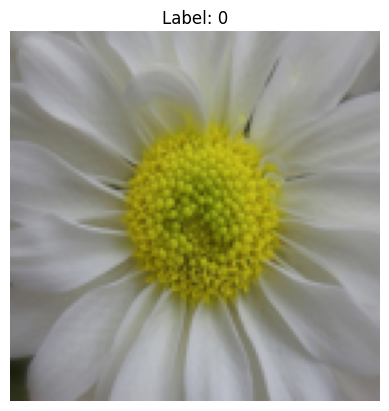

In [23]:
import matplotlib.pyplot as plt

image, label = dataset[0]

# convert CHW → HWC
img = image.permute(1, 2, 0)

plt.imshow(img)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

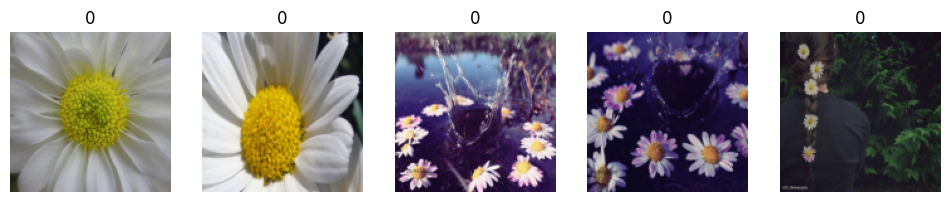

In [24]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    image, label = dataset[i]
    img = image.permute(1, 2, 0)

    axes[i].imshow(img)
    axes[i].set_title(label)
    axes[i].axis("off")

plt.show()

# Sample image (one per class)

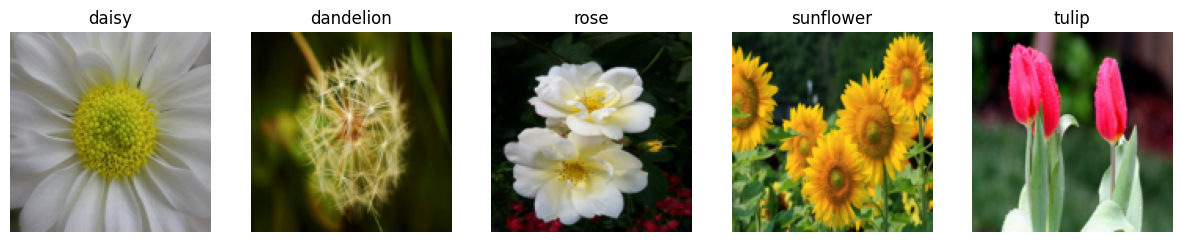

In [25]:
# Build Class-wise index mapping
class_indices = {cls: [] for cls in dataset.classes}

for idx in range(len(dataset)):
    _, label = dataset[idx]
    class_name = dataset.classes[label]
    class_indices[class_name].append(idx)
# pick one sample per class
selected_indices = []

for cls in dataset.classes:
    selected_indices.append(class_indices[cls][0])  # first image per class
# Visualize one sample per class
fig, axes = plt.subplots(1, len(selected_indices), figsize=(15, 3))

for i, idx in enumerate(selected_indices):
    image, label = dataset[idx]
    img = image.permute(1, 2, 0)

    axes[i].imshow(img)
    axes[i].set_title(dataset.classes[label])
    axes[i].axis("off")

plt.show()